In [1]:
import pandas as pd
import numpy as np

#Load merged dataset
merged_df = pd.read_csv("datasets/cleaned/final_merged_dataset.csv")
merged_df.head()

,FIPS,county,rural_urban,incidence_rate,avg_annual_count,percent_late_stage,median_income_$,total_pop,uninsured_pop,percent_uninsured,poverty_rate
0,6113,Yolo County,Urban,26.0,15.0,51.0,70228.0,215938.0,10466.0,4.846762,17.5
1,6057,Nevada County,Rural,23.6,6.0,45.5,66096.0,NaN,NaN,NaN,12.4
2,6041,Marin County,Urban,23.0,17.0,37.2,115246.0,255421.0,8987.0,3.518505,7.5
3,6111,Ventura County,Urban,21.5,54.0,43.9,88131.0,840257.0,73921.0,8.797427,9.9
4,6007,Butte County,Urban,21.3,12.0,44.3,52537.0,223229.0,13734.0,6.152426,21.4


### **Univariate Analysis**

1. Distribution of Breast Cancer Incidence Rate

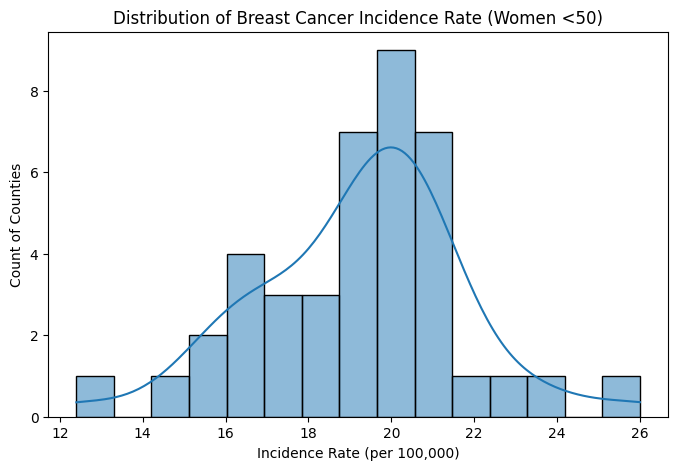

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(merged_df["incidence_rate"], bins=15, kde=True)
plt.title("Distribution of Breast Cancer Incidence Rate (Women <50)")
plt.xlabel("Incidence Rate (per 100,000)")
plt.ylabel("Count of Counties")
plt.show()

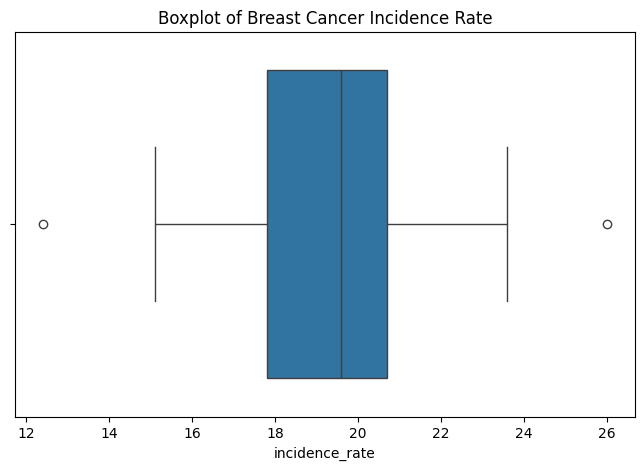

In [3]:
# Boxplot to detect outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=merged_df["incidence_rate"])
plt.title("Boxplot of Breast Cancer Incidence Rate")
plt.show()

In [4]:
# Summary Statistics
merged_df["incidence_rate"].describe()

count    41.000000
mean     19.234146
std       2.487530
min      12.400000
25%      17.800000
50%      19.600000
75%      20.700000
max      26.000000
Name: incidence_rate, dtype: float64

2. Distribution of Median Household Income

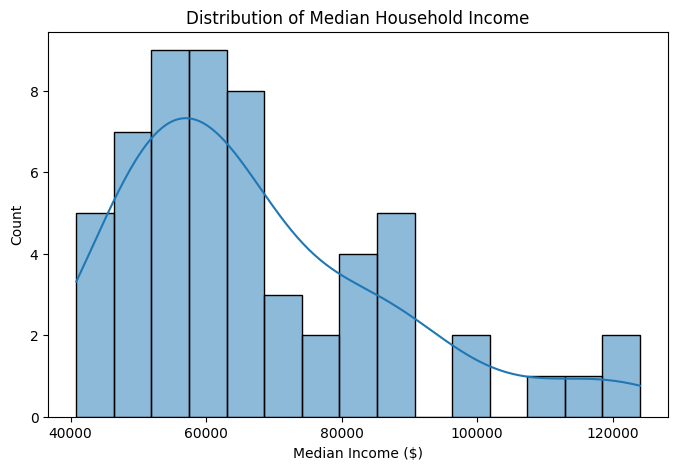

count        58.000000
mean      67713.603448
std       20213.449856
min       40846.000000
25%       53430.500000
50%       62516.000000
75%       80508.500000
max      124055.000000
Name: median_income_$, dtype: float64

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df["median_income_$"], bins=15, kde=True)
plt.title("Distribution of Median Household Income")
plt.xlabel("Median Income ($)")
plt.show()

merged_df["median_income_$"].describe()

3. Distribution of Uninsured Rate

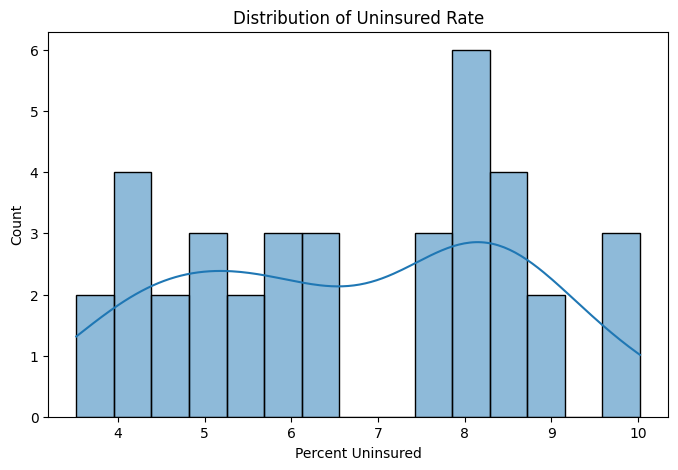

count    37.000000
mean      6.727868
std       1.899300
min       3.518505
25%       5.098101
50%       6.495238
75%       8.286419
max      10.025384
Name: percent_uninsured, dtype: float64

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df["percent_uninsured"], bins=15, kde=True)
plt.title("Distribution of Uninsured Rate")
plt.xlabel("Percent Uninsured")
plt.show()

merged_df["percent_uninsured"].describe()

4. Distribution of Poverty Rate

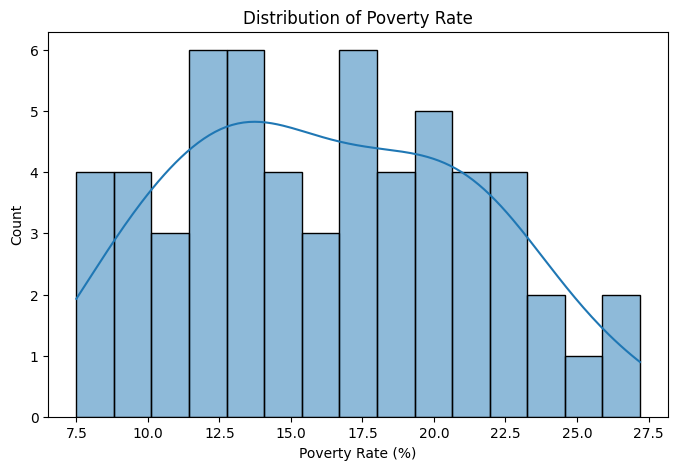

count    58.000000
mean     16.294828
std       5.064684
min       7.500000
25%      12.400000
50%      15.900000
75%      20.300000
max      27.200000
Name: poverty_rate, dtype: float64

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(merged_df["poverty_rate"], bins=15, kde=True)
plt.title("Distribution of Poverty Rate")
plt.xlabel("Poverty Rate (%)")
plt.show()

merged_df["poverty_rate"].describe()

### **Multivariate Analysis**

Question: Do counties with higher poverty rates have higher late-stage cancer rates?

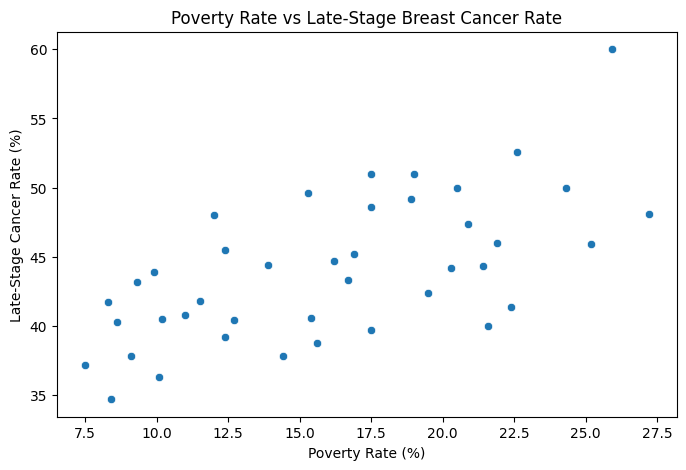

In [8]:
# Poverty vs Late Stage Cancer
plt.figure(figsize=(8,5))
sns.scatterplot(x=merged_df["poverty_rate"], y=merged_df["percent_late_stage"])

plt.title("Poverty Rate vs Late-Stage Breast Cancer Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Late-Stage Cancer Rate (%)")
plt.show()

Median Incomve vs Cancer Incidence Rate

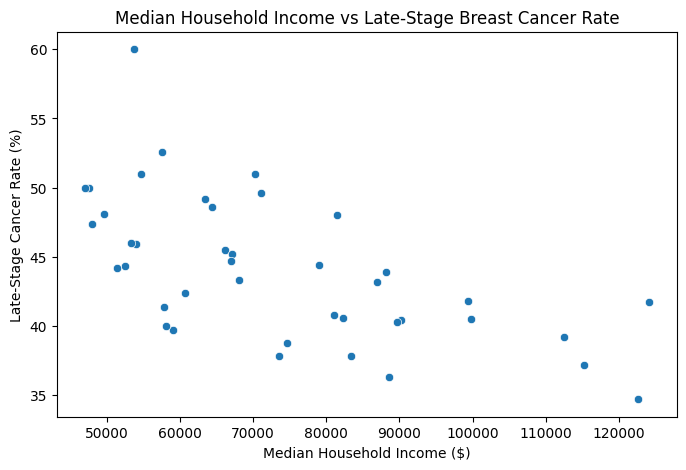

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=merged_df["median_income_$"], y=merged_df["percent_late_stage"])

plt.title("Median Household Income vs Late-Stage Breast Cancer Rate")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Late-Stage Cancer Rate (%)")
plt.show()

Uninsured Rate vs Cancer Incidence Rate

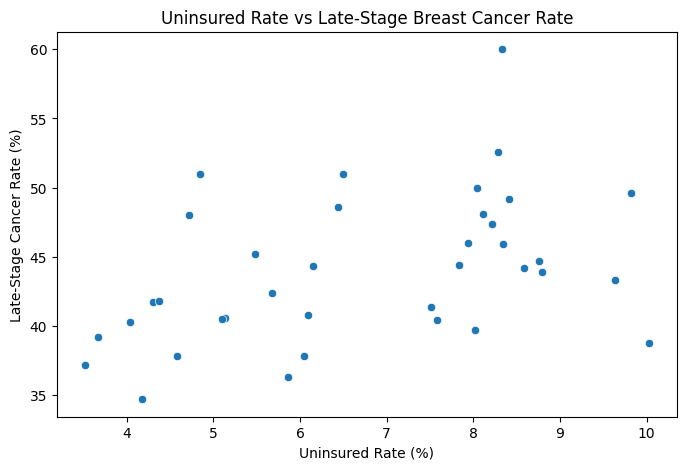

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=merged_df["percent_uninsured"], y=merged_df["percent_late_stage"])

plt.title("Uninsured Rate vs Late-Stage Breast Cancer Rate")
plt.xlabel("Uninsured Rate (%)")
plt.ylabel("Late-Stage Cancer Rate (%)")
plt.show()

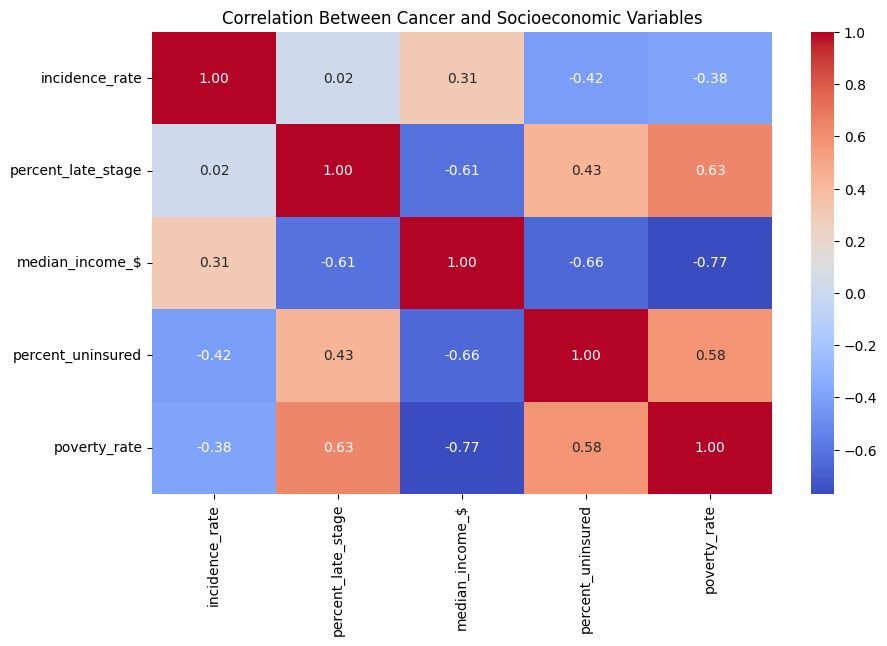

In [11]:
# Finding Correlation between variables

numeric_df = merged_df[[
    "incidence_rate",
    "percent_late_stage",
    "median_income_$",
    "percent_uninsured",
    "poverty_rate"
]]

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Cancer and Socioeconomic Variables")
plt.show()

Comparing Rural vs Urban Counties

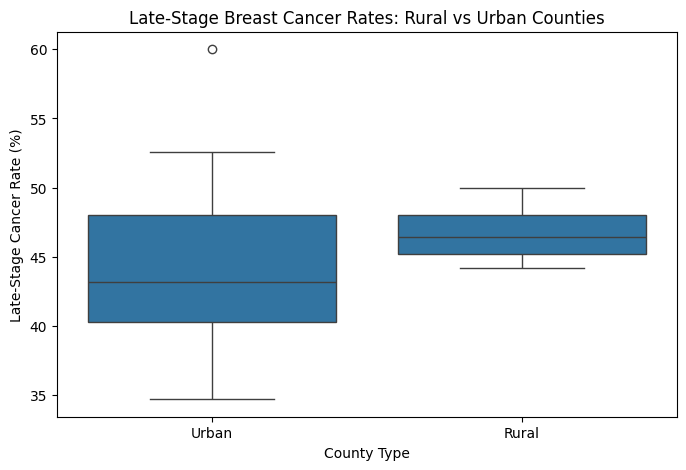

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=merged_df["rural_urban"],
    y=merged_df["percent_late_stage"]
)

plt.title("Late-Stage Breast Cancer Rates: Rural vs Urban Counties")
plt.xlabel("County Type")
plt.ylabel("Late-Stage Cancer Rate (%)")

plt.show()

Identifying Counties with High Late-Stage Cancer Rates

In [14]:
# Find counties with unusually high late-stage cancer rates
high_late_stage = merged_df[
    merged_df["percent_late_stage"] >
    merged_df["percent_late_stage"].quantile(0.90)
]

high_late_stage[[
    "county",
    "percent_late_stage",
    "poverty_rate",
    "percent_uninsured",
    "median_income_$"
]]

,county,percent_late_stage,poverty_rate,percent_uninsured,median_income_$
0,Yolo County,51.0,17.5,4.846762,70228.0
15,Shasta County,51.0,19.0,6.495238,54667.0
19,Merced County,60.0,25.9,8.330634,53672.0
40,Madera County,52.6,22.6,8.286419,57585.0
